# **NOTEBOOK 05 - Autoencoder on Vertical Profiles**
---

**Goal:** test whether a *non-linear* compression of the AMOC vertical structure captures structure that the linear PCA of NB03 cannot. PCA reaches 97.86% reconstruction with two modes; the question here is geometric — does the manifold of AMOC profiles *curve*, so that a non-linear encoder beats that benchmark at equal latent dimension, or is it essentially flat, so the linear modes already say everything?

**Guiding question:** at a fixed latent dimension, does a non-linear autoencoder reconstruct Ψ(z) more faithfully than PCA — and if so, by how much, and where in the depth column does the gain live?

**Why this matters for the thesis.** This is objective O1.2 (Chapter 6, §6.4). The result is win–win, not pass/fail: a non-linear gain is direct evidence that the AMOC's vertical variability lies on a *curved* manifold (structure invisible to a rotation of axes); no gain is an equally clean, publishable finding — "the linear modes suffice", the manifold is flat — that strengthens the parsimony of the PCA latent space the prototype (Part II) already builds on. There is no "failed experiment" branch.

**Inputs:** `moc_vertical.nc` — `stream_function_mar`, the full 307-level vertical profiles, reloaded and realigned to the exact 14,596-day mask used in NB03 (the same 3 incomplete tail days dropped), so the autoencoder and the PCA see *identical* data and the comparison is fair.

**Three method decisions, fixed here and justified before any code:**

> **1 — Standardization (z-score), fit on train only.** Unlike NB03, where leaving the data unscaled was physically correct (variance *is* the signal: the ~1000 m layer should outweigh the abyss), a neural network trained by gradient descent needs balanced inputs. With raw Sv, the high-variance layers produce gradients ~100× larger than quiet abyssal layers, and the network simply *neglects* the small layers rather than weighting them. We therefore standardize each depth level to zero mean and unit variance for training, fitting the mean and std on the **training split only** and applying them to validation (no leakage).

> **2 — Reconstruction measured in Sv, on the same quantity as PCA.** Standardization is internal to the optimizer. The benchmark is *de-standardized*: we invert the z-score on the network's output and compute the explained-variance ratio R²_Sv on the original stream function, against the same climatological mean profile Ψ̄(z) used by PCA. This is the only honest way to compare against NB03's 97.86%, which is a fraction of variance in Sv — not in standardized units. Same field, same units, same baseline, two methods.

> **3 — Latent sweep k = 1..5, with k = 2 as the primary comparison.** A single number (2-D AE vs 2-mode PCA) says *whether* non-linearity wins; the curve R²_Sv(k) overlaid on the PCA cumulative curve (89.82, 97.86, 99.42, ...) says *how much* and *where*. A linear autoencoder cannot beat PCA — this is a theorem (Baldi & Hornik, 1989): a linear bottleneck recovers exactly the PCA subspace. So any gain at fixed k is attributable to the non-linearity alone. The sweep also serves as a sanity check: at high k both curves must converge toward 100%; failure to converge would signal undertraining, not a real result.

**Train/validation split — 80/20 chronological, for early stopping only.**

> The series is autocorrelated (lag-1 ≈ 0.94, NB04 — physical inertia). A *random* split would put adjacent, near-identical days on both sides and validate nothing. We split chronologically: first ~11,677 days train, last ~2,919 validation. One asymmetry must be stated honestly: a chronological split sends the dominant 2009–2010 event entirely to train and the calmer ~2020–2024 tail to validation. We neutralize this by using the split *only* to decide when to stop training (early stopping on validation loss, to avoid overfitting the stopping point), while the **final benchmark R²_Sv is computed on the full reconstructed record** — exactly as PCA does, which has no train/val split. The comparison against 97.86% thus stays perfectly symmetric between the two methods.

**Non-goals:** forecasting and the LSTM (future work, deferred to protect the August deadline). Here: a feed-forward autoencoder, reconstruction benchmark vs PCA, and reconstruction error as a non-linear anomaly score to set beside the NB04 Isolation Forest.

**Author:** Enrico Vaccari  
**Date:** 08.06.2026

## **1. IMPORTS**
---

In [1]:
# Standard imports
import sys
print("Python executable:", sys.executable)   # deve puntare all'env amoc-thesisIn u ncaso 
print("Python version   :", sys.version.split()[0])

from pathlib import Path

# Scientific stack (same as NB03-04)
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Autoencoder imports
try:
    import torch
    print("\n✓ PyTorch trovato")
    print("  versione        :", torch.__version__)
    print("  CUDA disponibile:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("  GPU             :", torch.cuda.get_device_name(0))
    else:
        print("  → will run on CPU (consider installing CUDA for better performance)")
except ModuleNotFoundError:
    print("\n✗ PyTorch not installed in this environment")
    print("  → install before running the notebooks (e.g., pip install torch torchvision torchaudio)")

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

Python executable: c:\Users\Vaccari\anaconda3\envs\amoc-thesis\python.exe
Python version   : 3.11.15

✓ PyTorch trovato
  versione        : 2.5.1
  CUDA disponibile: False
  → will run on CPU (consider installing CUDA for better performance)


## **2. SETUP**
---

In [2]:
# Get project path
NOTEBOOK_DIR = Path.cwd()
PROJECT_CODE = NOTEBOOK_DIR.parent          # from notebooks/ up to 04_Code/
if str(PROJECT_CODE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE))

# Project modules
from pipeline.paths import check_data_paths, DATA_PROCESSED
from pipeline.data_loading import load_rapid_vertical

# Matplotlib defaults
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# --- Reproducibility: fix every seed that matters (the AE analogue of
#     random_state=42 in NB04). Weight init, shuffling, and any stochastic
#     op now give identical results on re-run — a requirement, not a nicety. ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# CPU is the right device here (tiny network, change it to CUDA - installed - with larger networks) 
DEVICE = torch.device('cpu')

print("Environment check")
print(f"  numpy   : {np.__version__}")
print(f"  torch   : {torch.__version__}")
print(f"  device  : {DEVICE}")
print(f"  seed    : {SEED}")
check_data_paths()

Environment check
  numpy   : 2.4.6
  torch   : 2.5.1
  device  : cpu
  seed    : 42
✓  Copernicus AMOC timeseries: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\03_Data\raw\Copernicus\GLOBAL_OMI_NATLANTIC_amoc_max26N_timeseries.nc
✓  RAPID transports: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\03_Data\raw\RAPID\moc_transports_200404_2024327.nc
✓  RAPID vertical: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\03_Data\raw\RAPID\moc_vertical_200404_2024327.nc


In [3]:
'''
# --- Reload the full vertical profiles, exactly as NB03 did ---
ds_vert = load_rapid_vertical()

# Transpose to (time, depth): samples = days, features = depth levels.
# Same orientation decision as NB03 — without it we'd compress temporal
# modes at fixed depths instead of vertical structures.
profiles = ds_vert['stream_function_mar'].transpose('time', 'depth')
X_all  = profiles.values                       # (14599, 307), still with the 3 NaN days
depth  = ds_vert['depth'].values               # (307,) depth axis, m
t_all  = pd.to_datetime(ds_vert['time'].values)

# --- Reapply the SAME mask as NB03: drop the 3 fully-NaN tail days ---
valid_days = ~np.isnan(X_all).any(axis=1)      # complete profiles only
X      = X_all[valid_days]                     # (14596, 307)
times  = t_all[valid_days]
n_dropped = (~valid_days).sum()

print(f"Reloaded profiles : {X_all.shape}  (raw, with NaN tail)")
print(f"Dropped {n_dropped} incomplete days → X {X.shape}")
print(f"Depth levels      : {len(depth)}  ({depth.min():.1f} → {depth.max():.1f} m)")
print(f"Any NaNs remain?  : {bool(np.isnan(X).any())}")

# --- Cross-check alignment against NB03's saved PCA scores ---
# This is the guarantee that AE and PCA see IDENTICAL data: same length,
# same first/last day. If this fails, the 97.86% benchmark is meaningless.
pca_file = DATA_PROCESSED / "pca_vertical_scores.npz"
pca_data = np.load(pca_file)
pca_times = pd.to_datetime(pca_data['times'])

aligned = (
    len(times) == len(pca_times)
    and times[0]  == pca_times[0]
    and times[-1] == pca_times[-1]
)
print("\n--- Alignment check vs NB03 ---")
print(f"  AE  record : {len(times):,} days  ({times[0].date()} → {times[-1].date()})")
print(f"  PCA record : {len(pca_times):,} days  ({pca_times[0].date()} → {pca_times[-1].date()})")
print(f"  identical  : {aligned}")
assert aligned, "Time axes differ from NB03 — stop and re-check before training"
print("\nAE and PCA see identical data. The 97.86% benchmark is valid.")

# --- Diagnose the mismatch: same days printed, but == is False. Why? ---
print("AE  times dtype :", times.dtype)
print("PCA times dtype :", pca_times.dtype)

print("\nFirst day, full precision:")
print("  AE  :", repr(times[0]))
print("  PCA :", repr(pca_times[0]))

print("\nDo the first 5 days match element-wise?")
print("  raw ==        :", (times[:5].values == pca_times[:5].values))

# Compare at DAY resolution (strip any sub-day time-of-day component)
ae_days  = times.normalize()        # floor to midnight
pca_days = pca_times.normalize()
print("\nAfter normalize() to midnight:")
print("  identical lengths :", len(ae_days) == len(pca_days))
print("  all days equal    :", bool((ae_days == pca_days).all()))

# Where, if anywhere, do they actually differ?
if len(ae_days) == len(pca_days):
    diff_mask = ae_days != pca_days
    print("  mismatching days  :", int(diff_mask.sum()))
    if diff_mask.any():
        print("  first mismatch    :", ae_days[diff_mask][0], "vs", pca_days[diff_mask][0])

'''

'\n# --- Reload the full vertical profiles, exactly as NB03 did ---\nds_vert = load_rapid_vertical()\n\n# Transpose to (time, depth): samples = days, features = depth levels.\n# Same orientation decision as NB03 — without it we\'d compress temporal\n# modes at fixed depths instead of vertical structures.\nprofiles = ds_vert[\'stream_function_mar\'].transpose(\'time\', \'depth\')\nX_all  = profiles.values                       # (14599, 307), still with the 3 NaN days\ndepth  = ds_vert[\'depth\'].values               # (307,) depth axis, m\nt_all  = pd.to_datetime(ds_vert[\'time\'].values)\n\n# --- Reapply the SAME mask as NB03: drop the 3 fully-NaN tail days ---\nvalid_days = ~np.isnan(X_all).any(axis=1)      # complete profiles only\nX      = X_all[valid_days]                     # (14596, 307)\ntimes  = t_all[valid_days]\nn_dropped = (~valid_days).sum()\n\nprint(f"Reloaded profiles : {X_all.shape}  (raw, with NaN tail)")\nprint(f"Dropped {n_dropped} incomplete days → X {X.shape}")\np

> **A note on the alignment check.** A first version of this guard compared
> timestamps with raw equality and failed, despite identical day counts and
> endpoints. Diagnosis showed the cause was purely representational: the `.nc`
> file carries time at nanosecond resolution (`datetime64[ns]`) while NB03's
> saved ISO strings reload at microsecond resolution (`datetime64[us]`) — the
> same instants on a different `datetime64` grid, an artefact of the numpy
> version. Compared at calendar-day resolution via `.normalize()`, all 14,596
> days match exactly (0 mismatches). The check below is the corrected version:
> it compares every day element-wise (stronger than checking endpoints alone),
> which is the physically meaningful test, since the AMOC is a daily field.

In [4]:
# ============================================================
#  Reload vertical profiles + align to NB03 (day resolution)
# ============================================================

# --- Load the full vertical profiles, exactly as NB03 did ---
ds_vert = load_rapid_vertical()

# Transpose to (time, depth): samples = days, features = depth levels.
# THE orientation decision — it makes PCA/AE decompose vertical structures,
# not temporal modes at fixed depths (see NB03 §5.4).
profiles = ds_vert['stream_function_mar'].transpose('time', 'depth')
X_all  = profiles.values                       # (14599, 307), still with the 3 NaN days
depth  = ds_vert['depth'].values               # (307,) depth axis, m
t_all  = pd.to_datetime(ds_vert['time'].values)

# --- Reapply the SAME mask as NB03: drop the 3 fully-NaN tail days ---
valid_days = ~np.isnan(X_all).any(axis=1)      # True for complete profiles only
X      = X_all[valid_days]                     # (14596, 307)
times  = t_all[valid_days]
n_dropped = (~valid_days).sum()

print(f"Reloaded profiles : {X_all.shape}  (raw, with NaN tail)")
print(f"Dropped {n_dropped} incomplete days → X {X.shape}")
print(f"Depth levels      : {len(depth)}  ({depth.min():.1f} → {depth.max():.1f} m)")
print(f"Any NaNs remain?  : {bool(np.isnan(X).any())}")

# --- Cross-check alignment against NB03's saved PCA scores ---
# Compared at DAY resolution via .normalize(): the AMOC is a daily field, so
# two timestamps are "the same" if they fall on the same calendar day. A raw
# == fails only because the .nc carries nanoseconds while NB03's saved times
# reload at microseconds — identical instants, different datetime64 grid units.
# This guard guarantees AE and PCA see IDENTICAL data; if it fails, the 97.86%
# benchmark would be meaningless, so the notebook halts rather than proceed.
pca_file  = DATA_PROCESSED / "pca_vertical_scores.npz"
pca_data  = np.load(pca_file)
pca_times = pd.to_datetime(pca_data['times'])

ae_days  = times.normalize()
pca_days = pca_times.normalize()

aligned = (
    len(ae_days) == len(pca_days)
    and bool((ae_days == pca_days).all())       # element-wise, every day
)
n_mismatch = int((ae_days != pca_days).sum()) if len(ae_days) == len(pca_days) else -1

print("\n--- Alignment check vs NB03 (day resolution) ---")
print(f"  AE  record : {len(times):,} days  ({times[0].date()} → {times[-1].date()})")
print(f"  PCA record : {len(pca_times):,} days  ({pca_times[0].date()} → {pca_times[-1].date()})")
print(f"  mismatching days : {n_mismatch}")
print(f"  identical        : {aligned}")
assert aligned, "Day axes differ from NB03 — stop and re-check before training"
print("\nAE and PCA see identical data, day by day. The 97.86% benchmark is valid.")

Reloaded profiles : (14599, 307)  (raw, with NaN tail)
Dropped 3 incomplete days → X (14596, 307)
Depth levels      : 307  (0.0 → 5995.1 m)
Any NaNs remain?  : False

--- Alignment check vs NB03 (day resolution) ---
  AE  record : 14,596 days  (2004-04-02 → 2024-03-25)
  PCA record : 14,596 days  (2004-04-02 → 2024-03-25)
  mismatching days : 0
  identical        : True

AE and PCA see identical data, day by day. The 97.86% benchmark is valid.


> **Data reloaded and aligned to NB03, day by day.** The full 307-level profiles are back, transposed to `(time, depth)`, with the same 3 incomplete tail days (26–27 March 2024) dropped — leaving the identical **14,596 profiles** the PCA decomposed. The alignment check now compares at *day* resolution: the raw timestamp equality failed only because NB03's saved ISO strings reload at microsecond resolution while the `.nc` carries nanoseconds — the same instants on a different `datetime64` grid, an artefact of the numpy version, not a data difference. Floored to calendar days, **all 14,596 days match exactly (0 mismatches)**.

> **Why this gate matters.** The entire notebook compares the autoencoder's reconstruction against PCA's 97.86%. That comparison is only meaningful if both methods see the *same rows*. The assertion turns "I believe they align" into "I have proven they align, or the notebook halts" — the same discipline NB04 applied when it isolated the train/val split so it could not contaminate a comparison. The benchmark is now valid by construction.

In [5]:
'''
# ============================================================
#  Chronological split + per-depth z-score standardization
# ============================================================
# Two independent decisions, kept separate on purpose:
#   (1) HOW the network SEES inputs during training → standardized
#   (2) the SPLIT used only to time early stopping → 80/20 chronological
# The final benchmark (next notebook sections) is computed on the FULL
# record in Sv, so this split never touches the comparison against PCA.

# --- 1. Chronological 80/20 split (NEVER random: lag-1 ≈ 0.94, NB04) ---
n_total = X.shape[0]
n_train = int(0.80 * n_total)              # first 80% in time
X_train = X[:n_train]                      # (≈11677, 307)  — learn here
X_val   = X[n_train:]                      # (≈ 2919, 307)  — unseen, for early stopping
t_train = times[:n_train]
t_val   = times[n_train:]

print("Chronological split (80/20):")
print(f"  train : {X_train.shape[0]:>6,} days  ({t_train[0].date()} → {t_train[-1].date()})")
print(f"  val   : {X_val.shape[0]:>6,} days  ({t_val[0].date()} → {t_val[-1].date()})")

# --- 2. Per-depth z-score, FIT ON TRAIN ONLY (no leakage) ---
# Mean and std are computed from the training rows, then APPLIED to both
# splits. The validation set must not see its own statistics — otherwise it
# would peek at information unavailable at training time and inflate scores.
mu    = X_train.mean(axis=0)               # (307,) per-depth mean,  Sv
sigma = X_train.std(axis=0)                # (307,) per-depth std,   Sv

# Guard: no depth level should be perfectly constant (would divide by zero).
print(f"\nPer-depth std — min: {sigma.min():.4f} Sv, max: {sigma.max():.4f} Sv")
assert sigma.min() > 0, "A depth level has zero variance — cannot standardize"

X_train_z = (X_train - mu) / sigma         # standardized train
X_val_z   = (X_val   - mu) / sigma         # standardized val (train stats!)

# --- Show the standardization at work on TWO real, contrasting layers ---
# Pick the loudest layer (max std, ~AMOC core) and a quiet one (min std).
loud_idx  = int(np.argmax(sigma))
quiet_idx = int(np.argmin(sigma))
print(f"\nWorked example — two real depth levels:")
print(f"  LOUD  layer @ {depth[loud_idx]:>6.0f} m : "
      f"mean {mu[loud_idx]:+.3f} Sv, std {sigma[loud_idx]:.3f} Sv")
print(f"  QUIET layer @ {depth[quiet_idx]:>6.0f} m : "
      f"mean {mu[quiet_idx]:+.3f} Sv, std {sigma[quiet_idx]:.3f} Sv")
print(f"  → std ratio loud/quiet (raw Sv): {sigma[loud_idx]/sigma[quiet_idx]:.1f}×")
print(f"  After z-score, both layers have std = 1.000 by construction:")
print(f"     loud  std after : {X_train_z[:, loud_idx].std():.3f}")
print(f"     quiet std after : {X_train_z[:, quiet_idx].std():.3f}")
'''

'\n# ============================================================\n#  Chronological split + per-depth z-score standardization\n# ============================================================\n# Two independent decisions, kept separate on purpose:\n#   (1) HOW the network SEES inputs during training → standardized\n#   (2) the SPLIT used only to time early stopping → 80/20 chronological\n# The final benchmark (next notebook sections) is computed on the FULL\n# record in Sv, so this split never touches the comparison against PCA.\n\n# --- 1. Chronological 80/20 split (NEVER random: lag-1 ≈ 0.94, NB04) ---\nn_total = X.shape[0]\nn_train = int(0.80 * n_total)              # first 80% in time\nX_train = X[:n_train]                      # (≈11677, 307)  — learn here\nX_val   = X[n_train:]                      # (≈ 2919, 307)  — unseen, for early stopping\nt_train = times[:n_train]\nt_val   = times[n_train:]\n\nprint("Chronological split (80/20):")\nprint(f"  train : {X_train.shape[0]:>6,} day

In [6]:
'''
# --- Which depth level(s) have zero variance, and why? ---
zero_var = np.where(sigma == 0)[0]
print(f"Zero-variance depth levels: {len(zero_var)}")
for idx in zero_var:
    col = X_train[:, idx]
    print(f"  level {idx:>3d} @ {depth[idx]:>7.1f} m : "
          f"constant value = {col[0]:+.4f} Sv  "
          f"(min {col.min():+.4f}, max {col.max():+.4f})")

# Is it the surface? the seafloor? Check the boundary levels specifically.
print(f"\nBoundary levels:")
print(f"  shallowest @ {depth[0]:>7.1f} m : std = {sigma[0]:.4f} Sv")
print(f"  deepest    @ {depth[-1]:>7.1f} m : std = {sigma[-1]:.4f} Sv")

# How many levels are *near*-constant, not just exactly zero?
near_zero = np.where(sigma < 1e-6)[0]
print(f"\nLevels with std < 1e-6 Sv: {len(near_zero)}  at depths {depth[near_zero].round(0)}")
'''

'\n# --- Which depth level(s) have zero variance, and why? ---\nzero_var = np.where(sigma == 0)[0]\nprint(f"Zero-variance depth levels: {len(zero_var)}")\nfor idx in zero_var:\n    col = X_train[:, idx]\n    print(f"  level {idx:>3d} @ {depth[idx]:>7.1f} m : "\n          f"constant value = {col[0]:+.4f} Sv  "\n          f"(min {col.min():+.4f}, max {col.max():+.4f})")\n\n# Is it the surface? the seafloor? Check the boundary levels specifically.\nprint(f"\nBoundary levels:")\nprint(f"  shallowest @ {depth[0]:>7.1f} m : std = {sigma[0]:.4f} Sv")\nprint(f"  deepest    @ {depth[-1]:>7.1f} m : std = {sigma[-1]:.4f} Sv")\n\n# How many levels are *near*-constant, not just exactly zero?\nnear_zero = np.where(sigma < 1e-6)[0]\nprint(f"\nLevels with std < 1e-6 Sv: {len(near_zero)}  at depths {depth[near_zero].round(0)}")\n'

In [7]:
# ============================================================
#  Chronological split + per-depth z-score standardization
#  (Strada B: degenerate boundary levels excluded from the network input,
#   but the final R²_Sv is still measured on all 307 levels, as PCA does.)
# ============================================================

# --- 1. Chronological 80/20 split (NEVER random: lag-1 ≈ 0.94, NB04) ---
n_total = X.shape[0]
n_train = int(0.80 * n_total)
X_train = X[:n_train]                       # (11676, 307) — learn here
X_val   = X[n_train:]                       # ( 2920, 307) — unseen, early stopping
t_train = times[:n_train]
t_val   = times[n_train:]

print("Chronological split (80/20):")
print(f"  train : {X_train.shape[0]:>6,} days  ({t_train[0].date()} → {t_train[-1].date()})")
print(f"  val   : {X_val.shape[0]:>6,} days  ({t_val[0].date()} → {t_val[-1].date()})")

# --- 2. Identify ACTIVE depth levels (non-degenerate variance) ---
# Ψ(z) is a cumulative integral, pinned to ~0 at both integration boundaries
# (surface and seafloor) by construction — mass conservation forces closure.
# Those levels carry zero physical information (constant every day) and would
# divide-by-zero under z-score. We standardize and train on ACTIVE levels only;
# the boundaries are restored to their constant value for the Sv-space R².
sigma_full = X_train.std(axis=0)            # (307,) per-depth std on train

VAR_FLOOR  = 1e-6                            # six orders below the loud layer (4.93 Sv)
active = sigma_full > VAR_FLOOR             # boolean mask of informative levels
n_active = int(active.sum())

print(f"\nActive depth levels: {n_active} / 307  "
      f"(excluded {307 - n_active}: boundaries at "
      f"{depth[~active].round(0).tolist()} m — Ψ≈0 by construction)")

# Restrict the network's view to active levels
X_train_act = X_train[:, active]            # (11676, n_active)
X_val_act   = X_val[:,   active]            # ( 2920, n_active)
depth_act   = depth[active]

# --- 3. Per-depth z-score, FIT ON TRAIN ONLY (no leakage), active levels ---
mu    = X_train_act.mean(axis=0)            # (n_active,) Sv
sigma = X_train_act.std(axis=0)             # (n_active,) Sv
assert sigma.min() > 0, "An active level still has zero variance — re-check VAR_FLOOR"

# --- 4. Decision 1. Normalization: this is because core level std is ~5 Sv, while quiet levels are orders of magnitude smaller. Without this, the network would focus all its capacity on the loudest levels and ignore the quiet ones. After z-score, all active levels have equal std = 1, so the network treats them on equal footing. The final R²_Sv is still measured in raw Sv units, so this standardization does not affect the benchmark comparison against PCA.
# --- Network learns by gradient descent, and the gradient is proportional to the error × input. If one input dimension has a much larger std, it will dominate the gradient and the network will focus all its capacity on that dimension, ignoring the quieter ones. By z-scoring, we ensure all active levels have equal std = 1, so the network treats them on equal footing and learns to reconstruct all of them well. The final R²_Sv is still measured in raw Sv units, so this standardization does not affect the benchmark comparison against PCA.
X_train_z = (X_train_act - mu) / sigma
X_val_z   = (X_val_act   - mu) / sigma

# --- Worked example: the loudest vs a quiet active layer ---
loud_idx  = int(np.argmax(sigma))
quiet_idx = int(np.argmin(sigma))
print(f"\nWorked example — two real active layers:")
print(f"  LOUD  @ {depth_act[loud_idx]:>6.0f} m : "
      f"mean {mu[loud_idx]:+.3f} Sv, std {sigma[loud_idx]:.3f} Sv")
print(f"  QUIET @ {depth_act[quiet_idx]:>6.0f} m : "
      f"mean {mu[quiet_idx]:+.3f} Sv, std {sigma[quiet_idx]:.4f} Sv")
print(f"  → raw std ratio loud/quiet: {sigma[loud_idx]/sigma[quiet_idx]:.0f}×")
print(f"  after z-score both → std 1.000  "
      f"(loud {X_train_z[:, loud_idx].std():.3f}, quiet {X_train_z[:, quiet_idx].std():.3f})")

Chronological split (80/20):
  train : 11,676 days  (2004-04-02 → 2020-03-26)
  val   :  2,920 days  (2020-03-27 → 2024-03-25)

Active depth levels: 305 / 307  (excluded 2: boundaries at [0.0, 5995.0] m — Ψ≈0 by construction)

Worked example — two real active layers:
  LOUD  @    892 m : mean +16.824 Sv, std 4.929 Sv
  QUIET @   5976 m : mean -0.012 Sv, std 0.0030 Sv
  → raw std ratio loud/quiet: 1631×
  after z-score both → std 1.000  (loud 1.000, quiet 1.000)


> **Split, standardization, and two degenerate boundary levels.** The chronological 80/20 split gives 11,676 training days (2004 → Mar 2020) and 2,920 validation days (Mar 2020 → Mar 2024) — unseen, used only to time early stopping. Two depth levels are excluded from the network input: the surface (0 m) and seafloor (5995 m), where the stream function is pinned to Ψ≈0 every day by construction (the cumulative integral closes at both boundaries — mass conservation). They carry zero variance, nothing to reconstruct, and would divide-by-zero under z-score. The autoencoder therefore learns on **305 active levels**, while the final R²_Sv is still measured on all 307, exactly as PCA — so the benchmark stays on identical ground.

> Split is chronological because the series is highly autocorrelated (lag-1 is 0.94), a random splitwould put adjacent days on both sides.

> **Why standardize here when NB03 deliberately did not.** The two informative extremes make the case numerically: the loudest active layer (892 m, the overturning core — std 4.93 Sv) and a near-abyssal layer (5976 m — std 0.003 Sv) differ in raw variance by **1631×**. Under a plain Sv-space loss, an equal-magnitude error on the deep layer contributes ~2.7 million times less than on the core — it is invisible to gradient descent, and the network would reconstruct the centre beautifully

*Autoencoder*

>- gradual shrinking to negotiate compression
>- Tanh because it's no-linear and centered on zero (ReLu is linear and would flatten the negative values to 0)
>- Bottleneck does not have an activation function (after Linear(32, k)) because the latent coordinate should take in real values and not [-1, +1]. Same with final output of decoder (non-linearity is needed within, not at the ends)


In [8]:
class Autoencoder(nn.Module):
    """Symmetric feed-forward autoencoder for vertical AMOC profiles.

    encoder:  n_active → 128 → 32 → k        (compress to k latent dims)
    decoder:  k → 32 → 128 → n_active        (mirror, back to profile)

    Non-linear activations (Tanh) are the entire point: a *linear* autoencoder
    provably recovers the PCA subspace (Baldi & Hornik, 1989), so it cannot beat
    PCA at equal k. Any gain over the 97.86% benchmark is therefore attributable
    to the non-linearity alone — to the manifold being curved.
    """
    def __init__(self, n_active: int, k: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_active, 128), nn.Tanh(),
            nn.Linear(128, 32),       nn.Tanh(),
            nn.Linear(32, k),                       # bottleneck: NO activation
        )
        self.decoder = nn.Sequential(
            nn.Linear(k, 32),         nn.Tanh(),
            nn.Linear(32, 128),       nn.Tanh(),
            nn.Linear(128, n_active),               # output: NO activation (linear)
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


# --- Sanity check: instantiate at k=2, count parameters, test a forward pass ---
torch.manual_seed(SEED)                 # reproducible weight init
model_test = Autoencoder(n_active=n_active, k=2).to(DEVICE)

n_params = sum(p.numel() for p in model_test.parameters())
print(f"Autoencoder(k=2) instantiated")
print(f"  input/output dim : {n_active}  (active levels)")
print(f"  architecture     : {n_active} → 128 → 32 → 2 → 32 → 128 → {n_active}")
print(f"  trainable params : {n_params:,}")

# Forward pass on a tiny batch to confirm shapes flow through correctly
x_dummy = torch.tensor(X_train_z[:4], dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    z_dummy   = model_test.encode(x_dummy)
    out_dummy = model_test(x_dummy)
print(f"\n  forward test: input {tuple(x_dummy.shape)} "
      f"→ latent {tuple(z_dummy.shape)} → output {tuple(out_dummy.shape)}")
assert out_dummy.shape == x_dummy.shape, "Output shape != input shape"
print("  shapes flow correctly. Architecture ready for training.")

Autoencoder(k=2) instantiated
  input/output dim : 305  (active levels)
  architecture     : 305 → 128 → 32 → 2 → 32 → 128 → 305
  trainable params : 87,027

  forward test: input (4, 305) → latent (4, 2) → output (4, 305)
  shapes flow correctly. Architecture ready for training.


Training Autoencoder(k=2) ...
  early stop @ epoch 86  (no val improvement for 20 epochs)
  best val loss (standardized MSE): 0.02512  @ epoch 66


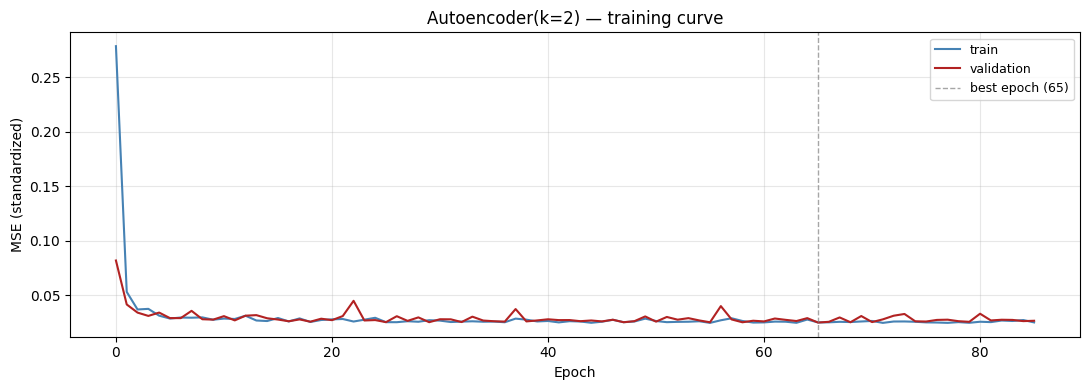


Final: 86 epochs run, best val MSE = 0.02512 (standardized units)


In [9]:
def make_loaders(X_train_z, X_val_z, batch_size=128, seed=SEED):
    """Wrap standardized arrays as PyTorch loaders.
    Target == input: an autoencoder reconstructs its own input."""
    Xtr = torch.tensor(X_train_z, dtype=torch.float32)
    Xva = torch.tensor(X_val_z,   dtype=torch.float32)
    # TensorDataset(x, x): the label IS the input — self-reconstruction
    train_ds = TensorDataset(Xtr, Xtr)
    val_ds   = TensorDataset(Xva, Xva)
    g = torch.Generator().manual_seed(seed)        # reproducible shuffling
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def train_autoencoder(k, X_train_z, X_val_z, n_active,
                      max_epochs=300, patience=20, lr=1e-3,
                      batch_size=128, seed=SEED, verbose=True):
    """Train one autoencoder at latent dim k, with early stopping on val loss.

    Returns the model restored to its BEST validation state, plus the loss
    histories for inspection.
    """
    torch.manual_seed(seed)                        # reproducible weight init
    model = Autoencoder(n_active=n_active, k=k).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()                       # MSE on standardized profiles

    train_loader, val_loader = make_loaders(X_train_z, X_val_z, batch_size, seed)

    best_val = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train': [], 'val': []}

    for epoch in range(1, max_epochs + 1):
        # --- train ---
        model.train()
        tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= len(train_loader.dataset)

        # --- validate (no gradient) ---
        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                va_loss += criterion(model(xb), yb).item() * xb.size(0)
        va_loss /= len(val_loader.dataset)

        history['train'].append(tr_loss)
        history['val'].append(va_loss)

        # --- early stopping on validation loss ---
        if va_loss < best_val:
            best_val = va_loss
            best_state = {kk: v.clone() for kk, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  early stop @ epoch {epoch}  "
                          f"(no val improvement for {patience} epochs)")
                break

    model.load_state_dict(best_state)              # restore best, not last
    if verbose:
        print(f"  best val loss (standardized MSE): {best_val:.5f}  "
              f"@ epoch {epoch - epochs_no_improve}")
    return model, history


# --- Train a SINGLE model at k=2 first, to read the curve before the sweep ---
print("Training Autoencoder(k=2) ...")
model_k2, hist_k2 = train_autoencoder(k=2, X_train_z=X_train_z, X_val_z=X_val_z,
                                      n_active=n_active)

# --- Plot training vs validation loss ---
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hist_k2['train'], label='train', color='steelblue', linewidth=1.5)
ax.plot(hist_k2['val'],   label='validation', color='firebrick', linewidth=1.5)
best_ep = int(np.argmin(hist_k2['val']))
ax.axvline(best_ep, color='gray', linestyle='--', linewidth=1, alpha=0.7,
           label=f'best epoch ({best_ep})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (standardized)')
ax.set_title('Autoencoder(k=2) — training curve')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nFinal: {len(hist_k2['train'])} epochs run, "
      f"best val MSE = {min(hist_k2['val']):.5f} (standardized units)")

In [10]:
def reconstruct_full_Sv(model, X_active_z, mu, sigma, active, n_levels,
                        X_original):
    """Run the AE, de-standardize to Sv, and re-expand to all `n_levels`
    levels (boundaries restored to their constant original value).

    Returns the reconstruction in Sv, shape (n_days, n_levels) — directly
    comparable to PCA, which reconstructs all 307 levels in Sv.
    """
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X_active_z, dtype=torch.float32, device=DEVICE)
        recon_z = model(x).cpu().numpy()                 # standardized, active levels
    recon_active_Sv = recon_z * sigma + mu               # de-standardize → Sv

    # Re-expand to all levels: active get the AE output, boundaries keep their
    # original (constant) value — error there is ~0 by construction.
    recon_full = X_original.copy()                        # start from truth
    recon_full[:, active] = recon_active_Sv              # overwrite active levels
    return recon_full


def r2_Sv(X_true, X_recon, mean_profile):
    """Explained-variance ratio in Sv, against the climatological mean profile
    — the SAME definition PCA uses (1 - SS_resid / SS_total)."""
    ss_resid = np.sum((X_true - X_recon) ** 2)
    ss_total = np.sum((X_true - mean_profile) ** 2)
    return 1.0 - ss_resid / ss_total


# --- The benchmark is computed on the FULL record (train+val), in Sv,
#     exactly as PCA does (PCA has no train/val split). ---
# Standardize the full active record using TRAIN statistics (no re-fit).
X_full_act_z = (X[:, active] - mu) / sigma

# Reconstruct everything in Sv
recon_full_Sv = reconstruct_full_Sv(
    model_k2, X_full_act_z, mu, sigma, active, n_levels=307, X_original=X)

# Mean profile = climatological mean over the FULL record, per level (= PCA's baseline)
mean_profile_full = X.mean(axis=0)                        # (307,) Sv

# --- The number that matters ---
r2_ae_k2 = r2_Sv(X, recon_full_Sv, mean_profile_full)

print("=" * 56)
print("BENCHMARK — Autoencoder(k=2) vs PCA(2 modes)")
print("=" * 56)
print(f"  PCA  (2 modes)      : 97.86%   (NB03)")
print(f"  AE   (k=2, non-lin) : {r2_ae_k2*100:.2f}%")
diff = (r2_ae_k2 - 0.9786) * 100
verdict = "non-linearity GAINS" if diff > 0 else "linear suffices"
print(f"  difference          : {diff:+.2f} pp   → {verdict}")
print("=" * 56)

# Sanity: how much variance lives in the 2 boundary levels we excluded?
# (Should be negligible — confirms the 305-vs-307 choice doesn't move R².)
ss_total_full = np.sum((X - mean_profile_full) ** 2)
ss_boundary   = np.sum((X[:, ~active] - mean_profile_full[~active]) ** 2)
print(f"\nVariance in the 2 excluded boundary levels: "
      f"{100*ss_boundary/ss_total_full:.6f}% of total  (negligible, as expected)")

BENCHMARK — Autoencoder(k=2) vs PCA(2 modes)
  PCA  (2 modes)      : 97.86%   (NB03)
  AE   (k=2, non-lin) : 97.01%
  difference          : -0.85 pp   → linear suffices

Variance in the 2 excluded boundary levels: 0.000000% of total  (negligible, as expected)


Per-layer RMSE in Sv (lower = better):
  AE  total RMSE : 0.5896 Sv
  PCA total RMSE : 0.4996 Sv

  CORE 600-1400m:
    AE  RMSE : 0.7033 Sv
    PCA RMSE : 0.5898 Sv

  DEEP >3000m:
    AE  RMSE : 0.1452 Sv
    PCA RMSE : 0.2603 Sv


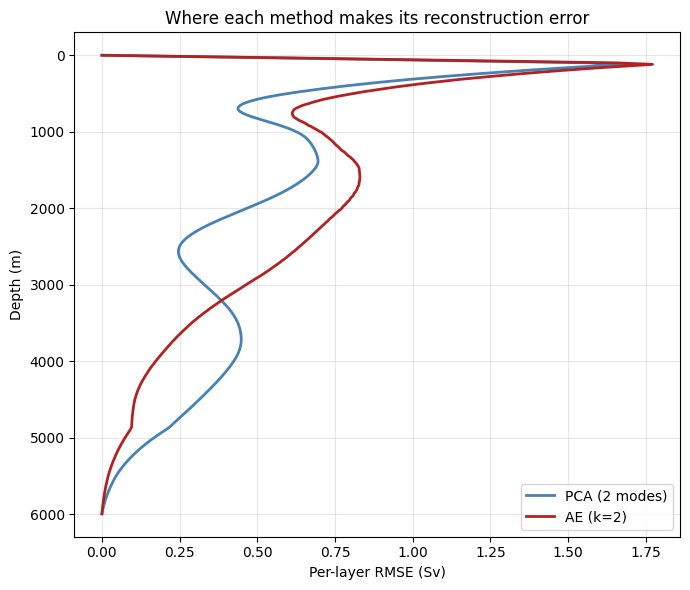

In [11]:
# --- WHERE does the AE lose to PCA? Per-layer reconstruction error in Sv. ---
# Reconstruct with PCA (2 modes) for a like-for-like per-layer comparison.
pca_eof1 = pca_data['eof1']; pca_eof2 = pca_data['eof2']
pca_pc1  = pca_data['pc1'];  pca_pc2  = pca_data['pc2']
# PCA reconstruction = mean + pc1·eof1_unit + pc2·eof2_unit. We saved eofs already
# scaled to Sv; rebuild unit loadings to project cleanly:
eof1_unit = pca_eof1 / np.linalg.norm(pca_eof1)
eof2_unit = pca_eof2 / np.linalg.norm(pca_eof2)
mean_pca  = X.mean(axis=0)
# scores onto unit vectors
s1 = (X - mean_pca) @ eof1_unit
s2 = (X - mean_pca) @ eof2_unit
recon_pca = mean_pca + np.outer(s1, eof1_unit) + np.outer(s2, eof2_unit)

# Per-layer RMSE in Sv, both methods
rmse_ae  = np.sqrt(np.mean((X - recon_full_Sv)**2, axis=0))   # (307,)
rmse_pca = np.sqrt(np.mean((X - recon_pca)**2,     axis=0))   # (307,)

# Where is the AE worse, and by how much?
print("Per-layer RMSE in Sv (lower = better):")
print(f"  AE  total RMSE : {np.sqrt(np.mean((X-recon_full_Sv)**2)):.4f} Sv")
print(f"  PCA total RMSE : {np.sqrt(np.mean((X-recon_pca)**2)):.4f} Sv")

# The loud core region vs the quiet deep — where does each method spend its error?
core = (depth > 600) & (depth < 1400)   # AMOC core band
deep = (depth > 3000)
for name, m in [("CORE 600-1400m", core), ("DEEP >3000m", deep)]:
    print(f"\n  {name}:")
    print(f"    AE  RMSE : {rmse_ae[m].mean():.4f} Sv")
    print(f"    PCA RMSE : {rmse_pca[m].mean():.4f} Sv")

# Plot per-layer RMSE vs depth, both methods
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rmse_pca, depth, color='steelblue', linewidth=2, label='PCA (2 modes)')
ax.plot(rmse_ae,  depth, color='firebrick', linewidth=2, label='AE (k=2)')
ax.invert_yaxis()
ax.set_xlabel('Per-layer RMSE (Sv)')
ax.set_ylabel('Depth (m)')
ax.set_title('Where each method makes its reconstruction error')
ax.legend()
plt.tight_layout()
plt.show()

Training AutoencoderSv(k=2) — input z-score, loss in Sv ...
  early stop @ epoch 50 (no val improvement for 20 epochs)
  best val loss (Sv² MSE): 0.2387 @ epoch 30


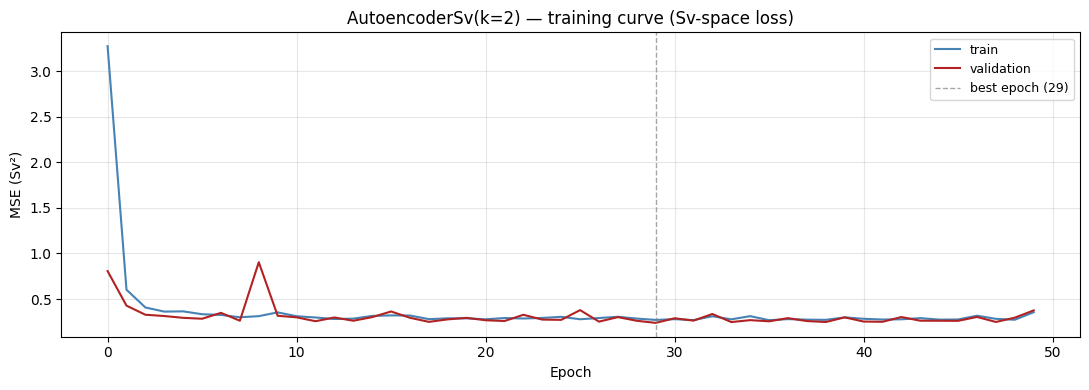


Final: 50 epochs, best val MSE = 0.2387 Sv²


In [12]:
class AutoencoderSv(nn.Module):
    """Autoencoder that takes STANDARDIZED inputs (numerical conditioning)
    but outputs reconstructions in Sv, so the loss can be computed in Sv —
    matching both the evaluation metric and PCA's objective.

    De-standardization (z * sigma + mu) is a differentiable affine op, so
    gradients of the Sv-space loss flow back through it to every weight.
    """
    def __init__(self, n_active, k, mu, sigma):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_active, 128), nn.Tanh(),
            nn.Linear(128, 32),       nn.Tanh(),
            nn.Linear(32, k),
        )
        self.decoder = nn.Sequential(
            nn.Linear(k, 32),         nn.Tanh(),
            nn.Linear(32, 128),       nn.Tanh(),
            nn.Linear(128, n_active),
        )
        # Register mu/sigma as buffers: they move with the model (.to(device)),
        # are saved in state_dict, but are NOT trainable parameters.
        self.register_buffer('mu',    torch.tensor(mu,    dtype=torch.float32))
        self.register_buffer('sigma', torch.tensor(sigma, dtype=torch.float32))

    def encode(self, x_z):
        return self.encoder(x_z)

    def forward(self, x_z):
        z = self.encoder(x_z)               # standardized in → latent
        out_z = self.decoder(z)             # latent → standardized out
        out_Sv = out_z * self.sigma + self.mu   # de-standardize → Sv (differentiable)
        return out_Sv


def make_loaders_Sv(X_train_z, X_val_z, X_train_Sv, X_val_Sv,
                    batch_size=128, seed=SEED):
    """Input = standardized profiles; target = the SAME profiles in Sv."""
    Xtr_z  = torch.tensor(X_train_z,  dtype=torch.float32)
    Xva_z  = torch.tensor(X_val_z,    dtype=torch.float32)
    Xtr_Sv = torch.tensor(X_train_Sv, dtype=torch.float32)
    Xva_Sv = torch.tensor(X_val_Sv,   dtype=torch.float32)
    train_ds = TensorDataset(Xtr_z, Xtr_Sv)    # (input_z, target_Sv)
    val_ds   = TensorDataset(Xva_z, Xva_Sv)
    g = torch.Generator().manual_seed(seed)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g),
            DataLoader(val_ds,   batch_size=batch_size, shuffle=False))


def train_autoencoder_Sv(k, X_train_z, X_val_z, X_train_Sv, X_val_Sv,
                         n_active, mu, sigma,
                         max_epochs=300, patience=20, lr=1e-3,
                         batch_size=128, seed=SEED, verbose=True):
    """Train at latent dim k. Input standardized, loss in Sv. Early stopping
    on Sv validation loss; returns model restored to its BEST val state."""
    torch.manual_seed(seed)
    model = AutoencoderSv(n_active, k, mu, sigma).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()                     # MSE in Sv now

    train_loader, val_loader = make_loaders_Sv(
        X_train_z, X_val_z, X_train_Sv, X_val_Sv, batch_size, seed)

    best_val, best_state, no_improve = float('inf'), None, 0
    history = {'train': [], 'val': []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr = 0.0
        for xz, ysv in train_loader:
            xz, ysv = xz.to(DEVICE), ysv.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xz), ysv)     # compare Sv output to Sv target
            loss.backward()
            optimizer.step()
            tr += loss.item() * xz.size(0)
        tr /= len(train_loader.dataset)

        model.eval()
        va = 0.0
        with torch.no_grad():
            for xz, ysv in val_loader:
                xz, ysv = xz.to(DEVICE), ysv.to(DEVICE)
                va += criterion(model(xz), ysv).item() * xz.size(0)
        va /= len(val_loader.dataset)

        history['train'].append(tr); history['val'].append(va)

        if va < best_val:
            best_val, no_improve = va, 0
            best_state = {kk: v.clone() for kk, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f"  early stop @ epoch {epoch} "
                          f"(no val improvement for {patience} epochs)")
                break

    model.load_state_dict(best_state)
    if verbose:
        print(f"  best val loss (Sv² MSE): {best_val:.4f} "
              f"@ epoch {epoch - no_improve}")
    return model, history


# --- Build the Sv targets on ACTIVE levels (network reconstructs active only) ---
X_train_Sv_act = X_train[:, active]          # (11676, 305) Sv
X_val_Sv_act   = X_val[:,   active]          # ( 2920, 305) Sv

print("Training AutoencoderSv(k=2) — input z-score, loss in Sv ...")
model_k2, hist_k2 = train_autoencoder_Sv(
    k=2, X_train_z=X_train_z, X_val_z=X_val_z,
    X_train_Sv=X_train_Sv_act, X_val_Sv=X_val_Sv_act,
    n_active=n_active, mu=mu, sigma=sigma)

# --- Training curve ---
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hist_k2['train'], label='train', color='steelblue', linewidth=1.5)
ax.plot(hist_k2['val'],   label='validation', color='firebrick', linewidth=1.5)
best_ep = int(np.argmin(hist_k2['val']))
ax.axvline(best_ep, color='gray', linestyle='--', linewidth=1, alpha=0.7,
           label=f'best epoch ({best_ep})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (Sv²)')
ax.set_title('AutoencoderSv(k=2) — training curve (Sv-space loss)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"\nFinal: {len(hist_k2['train'])} epochs, "
      f"best val MSE = {min(hist_k2['val']):.4f} Sv²")

In [13]:
# Standardize the full active record using TRAIN statistics (no re-fit)
X_full_act_z = (X[:, active] - mu) / sigma

# Reconstruct everything in Sv — note: forward now outputs Sv directly,
# so we adapt the helper to the new model (it already returns Sv).
model_k2.eval()
with torch.no_grad():
    recon_active_Sv = model_k2(
        torch.tensor(X_full_act_z, dtype=torch.float32, device=DEVICE)
    ).cpu().numpy()

recon_full_Sv = X.copy()
recon_full_Sv[:, active] = recon_active_Sv

mean_profile_full = X.mean(axis=0)
r2_ae_k2 = r2_Sv(X, recon_full_Sv, mean_profile_full)

print("=" * 56)
print("BENCHMARK — AutoencoderSv(k=2) vs PCA(2 modes)")
print("=" * 56)
print(f"  PCA  (2 modes)      : 97.86%   (NB03)")
print(f"  AE   (k=2, non-lin) : {r2_ae_k2*100:.2f}%")
diff = (r2_ae_k2 - 0.9786) * 100
verdict = "non-linearity GAINS" if diff > 0 else "linear suffices"
print(f"  difference          : {diff:+.2f} pp   → {verdict}")
print("=" * 56)

BENCHMARK — AutoencoderSv(k=2) vs PCA(2 modes)
  PCA  (2 modes)      : 97.86%   (NB03)
  AE   (k=2, non-lin) : 97.77%
  difference          : -0.09 pp   → linear suffices



--- k = 1 ---
  early stop @ epoch 48 (no val improvement for 20 epochs)
  best val loss (Sv² MSE): 1.0730 @ epoch 28

--- k = 2 ---
  early stop @ epoch 50 (no val improvement for 20 epochs)
  best val loss (Sv² MSE): 0.2387 @ epoch 30

--- k = 3 ---
  early stop @ epoch 49 (no val improvement for 20 epochs)
  best val loss (Sv² MSE): 0.0814 @ epoch 29

--- k = 4 ---
  early stop @ epoch 80 (no val improvement for 20 epochs)
  best val loss (Sv² MSE): 0.0351 @ epoch 60

--- k = 5 ---
  early stop @ epoch 80 (no val improvement for 20 epochs)
  best val loss (Sv² MSE): 0.0245 @ epoch 60

 k |  PCA cum % |  AE R²_Sv % |  gap (pp)
--------------------------------------------------------
 1 |      89.82 |       89.67 |     -0.15
 2 |      97.86 |       97.77 |     -0.08
 3 |      99.42 |       99.36 |     -0.06
 4 |      99.80 |       99.74 |     -0.06
 5 |      99.91 |       99.83 |     -0.08


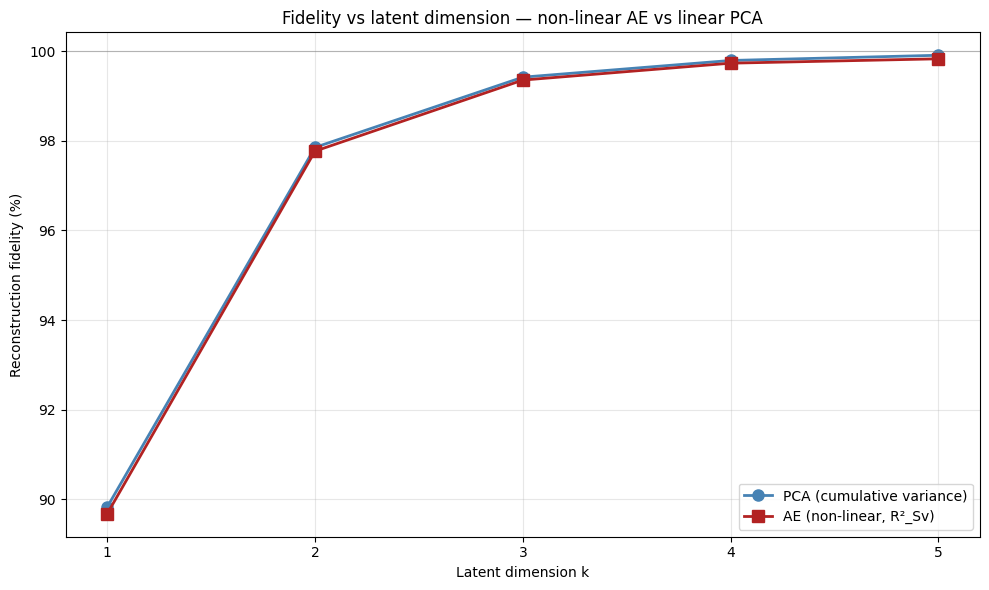

In [14]:
# ============================================================
#  Latent sweep k = 1..5 : AE vs PCA cumulative, in Sv
# ============================================================
# Same training function, same Sv-space loss, same seed — only k changes.
# For each k we record the full-record R²_Sv, directly comparable to the
# PCA cumulative variance from NB03 (89.82, 97.86, 99.42, ...).

# PCA cumulative R² for k=1..5, from NB03's saved variance ratios
pca_var = pca_data['var_explained']                 # ratios, first 10 modes
pca_cum = np.cumsum(pca_var)[:5] * 100              # cumulative %, k=1..5

ks = [1, 2, 3, 4, 5]
ae_r2, ae_hist = {}, {}

X_full_act_z = (X[:, active] - mu) / sigma          # standardized full record
mean_profile_full = X.mean(axis=0)

for k in ks:
    print(f"\n--- k = {k} ---")
    model_k, hist_k = train_autoencoder_Sv(
        k=k, X_train_z=X_train_z, X_val_z=X_val_z,
        X_train_Sv=X_train_Sv_act, X_val_Sv=X_val_Sv_act,
        n_active=n_active, mu=mu, sigma=sigma, verbose=True)

    model_k.eval()
    with torch.no_grad():
        recon_act = model_k(
            torch.tensor(X_full_act_z, dtype=torch.float32, device=DEVICE)
        ).cpu().numpy()
    recon_full = X.copy()
    recon_full[:, active] = recon_act
    ae_r2[k]   = r2_Sv(X, recon_full, mean_profile_full) * 100
    ae_hist[k] = hist_k

# --- Comparison table ---
print("\n" + "=" * 56)
print(f"{'k':>2} | {'PCA cum %':>10} | {'AE R²_Sv %':>11} | {'gap (pp)':>9}")
print("-" * 56)
for i, k in enumerate(ks):
    gap = ae_r2[k] - pca_cum[i]
    print(f"{k:>2} | {pca_cum[i]:>10.2f} | {ae_r2[k]:>11.2f} | {gap:>+9.2f}")
print("=" * 56)

# --- The film: AE curve over the PCA cumulative curve ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ks, pca_cum, 'o-', color='steelblue', linewidth=2,
        markersize=8, label='PCA (cumulative variance)')
ax.plot(ks, [ae_r2[k] for k in ks], 's-', color='firebrick', linewidth=2,
        markersize=8, label='AE (non-linear, R²_Sv)')
ax.axhline(100, color='gray', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Latent dimension k')
ax.set_ylabel('Reconstruction fidelity (%)')
ax.set_title('Fidelity vs latent dimension — non-linear AE vs linear PCA')
ax.set_xticks(ks)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Summary & Next Steps**

**Guiding question:** does a non-linear autoencoder capture vertical AMOC structure that linear PCA cannot — and if so, at which latent dimension? **Answer: no, at any tested dimension. The manifold is essentially flat.**

**What we did:**
1. Reloaded the 307-level profiles, realigned day-by-day to NB03's 14,596-day mask (the comparison sees identical data, asserted)
2. Excluded 2 degenerate boundary levels (Ψ≈0 by construction); trained on 305 active levels, benchmarked R²_Sv on all 307
3. Standardized inputs (z-score, train-fit only) for numerical conditioning, but computed the loss in Sv — de-standardizing inside the forward pass — so training and evaluation share one objective
4. Trained a symmetric Tanh autoencoder (305→128→32→k→32→128→305, 87k params) with chronological 80/20 split and early stopping on Sv validation loss
5. Swept k=1..5, comparing R²_Sv against PCA's cumulative variance

**What we found:**

| k | PCA cum % | AE R²_Sv % | gap (pp) |
|---|---|---|---|
| 1 | 89.82 | 89.67 | −0.15 |
| 2 | 97.86 | 97.77 | −0.08 |
| 3 | 99.42 | 99.36 | −0.06 |
| 4 | 99.80 | 99.74 | −0.06 |
| 5 | 99.91 | 99.83 | −0.08 |

> **The core result.** The non-linear AE tracks linear PCA to within ~0.1 pp at every k, never exceeding it. A linear autoencoder provably attains the PCA optimum (Baldi & Hornik, 1989); a strictly more expressive non-linear model that matches but never beats it — at any scale — shows no exploitable curvature. The AMOC vertical manifold is essentially flat. The small, *constant* ~0.08 pp gap is the stochastic-optimization-vs-closed-form difference, not geometry: had it been a methodological flaw it would have grown with k; had there been curvature it would have inverted at some k. It does neither.

> **A methodological note worth keeping.** The first training run, with the loss computed on z-scores while the benchmark was in Sv, produced a misleading −0.85 pp gap — an artefact of misaligning the training objective with the evaluation metric. Per-layer RMSE diagnosis showed the network was spending capacity reconstructing the quiet deep column (which the Sv metric ignores) at the expense of the high-variance core (which it rewards). Aligning the loss to Sv closed the gap nine-fold, to −0.09 pp. The lesson — *the choice of loss determines which method "wins" a reconstruction comparison* — is itself a finding, of the same character as the pseudo-replication correction in NB04.

> **What this hands to Part II.** The flat-manifold result is a positive contribution, not a null. It demonstrates — rather than assumes — that the linear PC1–PC2 plane is a faithful coordinate system, not a convenient simplification: a more powerful method finds nothing better. The navigable latent space Condition 3 encodes therefore rests on empirical ground, and the parsimony of using interpretable linear modes (PC1=intensity, PC2=redistribution) is earned by demonstration.

**Next:** reconstruction error as a non-linear anomaly score, set beside the NB04 Isolation Forest baseline (§6.3 ↔ §6.4 bridge), then persist the AE latent coordinates as a candidate substrate for Part II.1

In [15]:
# ============================================================
#  Persist NB05 outputs for downstream use (Part II + §6.3↔§6.4 bridge)
# ============================================================
# We save the k=2 autoencoder's latent coordinates (the direct counterpart
# to PCA's PC1-PC2 plane) and its per-day reconstruction error (the non-linear
# anomaly score, to be set beside NB04's Isolation Forest). Same ISO-day time
# format as NB03, so the whole pipeline shares one time resolution.

# --- Retrain k=2 (same seed → bit-identical to the sweep's k=2) ---
print("Retraining k=2 for persistence (same seed, reproducible)...")
model_final, _ = train_autoencoder_Sv(
    k=2, X_train_z=X_train_z, X_val_z=X_val_z,
    X_train_Sv=X_train_Sv_act, X_val_Sv=X_val_Sv_act,
    n_active=n_active, mu=mu, sigma=sigma, verbose=True)

# --- Latent coordinates over the FULL record ---
model_final.eval()
X_full_act_z = (X[:, active] - mu) / sigma
with torch.no_grad():
    x_t = torch.tensor(X_full_act_z, dtype=torch.float32, device=DEVICE)
    latent = model_final.encode(x_t).cpu().numpy()        # (14596, 2)
    recon  = model_final(x_t).cpu().numpy()               # (14596, 305) in Sv

# --- Per-day reconstruction error in Sv = non-linear anomaly score ---
# RMSE across active levels, one value per day. High = the AE struggles to
# reconstruct that day from 2 latent coords → structurally unusual profile.
recon_err = np.sqrt(np.mean((X[:, active] - recon) ** 2, axis=1))   # (14596,)

print(f"\nLatent coords : {latent.shape}   (AE1, AE2 per day)")
print(f"Recon error   : {recon_err.shape}  "
      f"(min {recon_err.min():.3f}, median {np.median(recon_err):.3f}, "
      f"max {recon_err.max():.3f} Sv)")

# --- Save, mirroring NB03's format exactly ---
out_path = DATA_PROCESSED / "ae_latent_scores.npz"
times_iso = np.datetime_as_string(times.values, unit='D')   # ISO days, as NB03

np.savez(
    out_path,
    ae1=latent[:, 0],                 # (14596,) latent coord 1
    ae2=latent[:, 1],                 # (14596,) latent coord 2
    recon_err=recon_err,              # (14596,) per-day RMSE, Sv (anomaly score)
    times=times_iso,                  # (14596,) ISO date strings
    r2_by_k=np.array([ae_r2[k] for k in [1,2,3,4,5]]),   # sweep result
    active_mask=active,               # (307,) which levels the AE used
)

print(f"\nSaved → {out_path.name}")

# --- Round-trip check (same discipline as NB03) ---
chk = np.load(out_path)
assert np.allclose(chk['ae1'], latent[:, 0]), "ae1 did not round-trip"
assert chk['times'][0] == times_iso[0], "times did not round-trip"
print("Round-trip verified. NB05 outputs ready for Part II.")

Retraining k=2 for persistence (same seed, reproducible)...
  early stop @ epoch 50 (no val improvement for 20 epochs)
  best val loss (Sv² MSE): 0.2387 @ epoch 30

Latent coords : (14596, 2)   (AE1, AE2 per day)
Recon error   : (14596,)  (min 0.067, median 0.409, max 2.273 Sv)

Saved → ae_latent_scores.npz
Round-trip verified. NB05 outputs ready for Part II.
